# 05 — Model Training

**AttriSense · Employee Attrition Prediction & Analytics System**

---

## Purpose

Train and tune four supervised classifiers to predict employee attrition. All training logic lives in `src/attrisense/models/`; this notebook orchestrates the run and displays computed results.

**Models:** Logistic Regression · Decision Tree · Random Forest · XGBoost

**Protocol:**
- Stratified 80/20 train/test split (`random_state=42`)
- 5-fold stratified cross-validation for hyperparameter tuning
- ROC-AUC as the CV scoring metric (appropriate for imbalanced data)
- Sklearn Pipelines: preprocessing + classifier fit together
- Best pipeline per model saved with Joblib

**Inputs:** `employee_attrition_featured.parquet`, `models/selected_features.json`

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from attrisense.config import load_config
from attrisense.models import (
    get_model_specs,
    prepare_training_data,
    run_training_pipeline,
    stratified_train_test_split,
)

config = load_config()

x, y, features = prepare_training_data(config)
x_train, x_test, y_train, y_test = stratified_train_test_split(x, y, config)

print(f"Features   : {len(features)}")
print(f"Train set  : {len(x_train):,} ({y_train.mean()*100:.1f}% attrition)")
print(f"Test set   : {len(x_test):,} ({y_test.mean()*100:.1f}% attrition)")
print(f"Random seed: {config.random_state}")

Features   : 37
Train set  : 1,176 (16.2% attrition)
Test set   : 294 (16.0% attrition)
Random seed: 42


## 1. Model Pipelines and Hyperparameter Grids

Each model uses a sklearn `Pipeline`: **preprocessor** (one-hot encoding for nominal columns; scaling only for Logistic Regression) followed by **classifier**.

Cross-validation tuning searches the grids below. Grids are intentionally small to keep runtime reasonable on ~1,200 training rows.

In [2]:
specs = get_model_specs(config)

for name, spec in specs.items():
    print(f"\n{name}")
    print(f"  Scale numeric: {spec['scale_numeric']}")
    print(f"  Param grid   : {spec['param_grid']}")


logistic_regression
  Scale numeric: True
  Param grid   : {'classifier__C': [0.01, 0.1, 1.0, 10.0], 'classifier__solver': ['lbfgs', 'saga']}

decision_tree
  Scale numeric: False
  Param grid   : {'classifier__max_depth': [3, 5, 8, 12, None], 'classifier__min_samples_split': [2, 10, 20], 'classifier__min_samples_leaf': [1, 5, 10]}

random_forest
  Scale numeric: False
  Param grid   : {'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [5, 10, None], 'classifier__min_samples_split': [2, 5, 10], 'classifier__max_features': ['sqrt', 'log2']}

xgboost
  Scale numeric: False
  Param grid   : {'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [3, 5, 7], 'classifier__learning_rate': [0.01, 0.05, 0.1], 'classifier__subsample': [0.8, 1.0], 'classifier__colsample_bytree': [0.8, 1.0]}


## 2. Train All Models

`GridSearchCV` with stratified 5-fold CV runs on the **training split only**. The test set is held out until after tuning completes.

This cell may take a few minutes — all metrics are computed at runtime.

In [3]:
report = run_training_pipeline(config)

print(f"Training complete — {len(report.results)} models saved")
print(f"Results JSON: {report.results_path}")
report.comparison

Training complete — 4 models saved
Results JSON: D:\Fun\AttriSense-Employee-Attrition-Prediction\models\training_results.json


,model,cv_score,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,logistic_regression,0.8354,0.7755,0.3882,0.7021,0.5000,0.8164
3,xgboost,0.8185,0.8265,0.4333,0.2766,0.3377,0.7657
2,random_forest,0.8089,0.8197,0.4167,0.3191,0.3614,0.7495
1,decision_tree,0.7294,0.7517,0.2969,0.4043,0.3423,0.6551


## 3. Test-Set Performance Comparison

Hold-out metrics on the 20% test split. ROC-AUC measures ranking quality; recall on the attrition class reflects how many leavers the model catches.

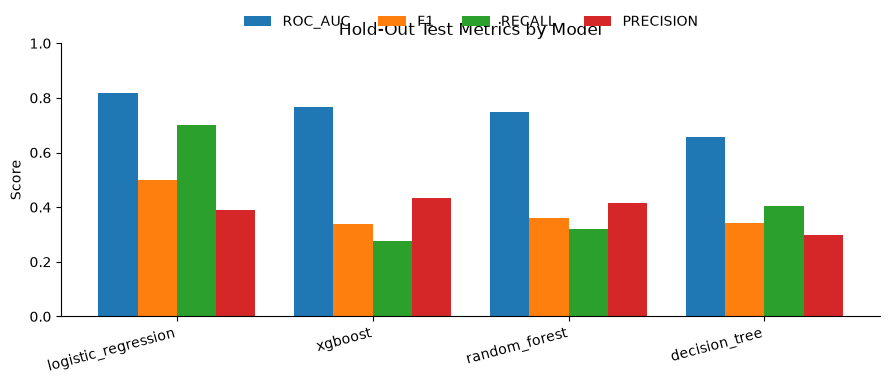

In [4]:
comparison = report.comparison.copy()
metrics = ["test_roc_auc", "test_f1", "test_recall", "test_precision"]

fig, ax = plt.subplots(figsize=(9, 4))
x_pos = range(len(comparison))
width = 0.2

for i, metric in enumerate(metrics):
    offset = (i - 1.5) * width
    ax.bar(
        [p + offset for p in x_pos],
        comparison[metric],
        width=width,
        label=metric.replace("test_", "").upper(),
    )

ax.set_xticks(list(x_pos))
ax.set_xticklabels(comparison["model"], rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Hold-Out Test Metrics by Model")
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.15))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Best Hyperparameters

Winning configuration from cross-validation for each model.

In [5]:
best_params = pd.DataFrame(
    [
        {
            "model": r.model_name,
            "cv_roc_auc": round(r.cv_best_score, 4),
            "best_params": json.dumps(r.best_params),
        }
        for r in report.results
    ]
)
best_params

,model,cv_roc_auc,best_params
0,logistic_regression,0.8354,"{""classifier__C"": 10.0, ""classifier__solver"": ..."
1,decision_tree,0.7294,"{""classifier__max_depth"": 3, ""classifier__min_..."
2,random_forest,0.8089,"{""classifier__max_depth"": null, ""classifier__m..."
3,xgboost,0.8185,"{""classifier__colsample_bytree"": 1.0, ""classif..."


## 5. Persisted Artifacts

Each saved pipeline includes preprocessing and the tuned classifier — ready for inference without re-fitting.

In [6]:
artifacts = pd.DataFrame(
    [{"model": r.model_name, "path": r.model_path} for r in report.results]
)
artifacts

,model,path
0,logistic_regression,D:\Fun\AttriSense-Employee-Attrition-Predictio...
1,decision_tree,D:\Fun\AttriSense-Employee-Attrition-Predictio...
2,random_forest,D:\Fun\AttriSense-Employee-Attrition-Predictio...
3,xgboost,D:\Fun\AttriSense-Employee-Attrition-Predictio...


**Next step:** `06_Model_Evaluation.ipynb` — confusion matrices, ROC curves, SHAP explanations, and final model selection for deployment.